#Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.model_selection import GridSearchCV

#Load Dataset

In [4]:
df = pd.read_csv("online_retail_II.csv")

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400265 entries, 0 to 400264
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      400265 non-null  object 
 1   StockCode    400265 non-null  object 
 2   Description  397828 non-null  object 
 3   Quantity     400265 non-null  int64  
 4   InvoiceDate  400265 non-null  object 
 5   Price        400265 non-null  float64
 6   Customer ID  320310 non-null  float64
 7   Country      400264 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 24.4+ MB


In [9]:
print("rows: ", df.shape[0])
print("columns: ",df.shape[0])

rows:  400265
columns:  400265


In [11]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [13]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


In [14]:
df.describe()

,Quantity,Price,Customer ID
count,400265.000000,400265.000000,320310.000000
mean,10.941136,4.840154,15334.609126
std,116.432155,147.952150,1677.022384
min,-9600.000000,-53594.360000,12346.000000
25%,1.000000,1.250000,13969.000000
50%,3.000000,2.100000,15271.000000
75%,12.000000,4.210000,16788.000000
max,19152.000000,25111.090000,18287.000000


In [15]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,2437
Quantity,0
InvoiceDate,0
Price,0
Customer ID,79955
Country,1


In [16]:
print("duplicate rows: ", df.duplicated().sum())

duplicate rows:  4724


In [17]:
df['Customer ID'].nunique()

3864

In [18]:
df['Country'].nunique()

38

In [19]:
df['Country'].value_counts()

,count
Country,
United Kingdom,369627
EIRE,7661
Germany,6484
France,4274
Netherlands,2244
Spain,1090
Switzerland,832
Sweden,784
Belgium,779


In [20]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400265 entries, 0 to 400264
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400265 non-null  object        
 1   StockCode    400265 non-null  object        
 2   Description  397828 non-null  object        
 3   Quantity     400265 non-null  int64         
 4   InvoiceDate  400265 non-null  datetime64[ns]
 5   Price        400265 non-null  float64       
 6   Customer ID  320310 non-null  float64       
 7   Country      400264 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 24.4+ MB


In [22]:
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2009-12-01 07:45:00
2010-10-18 15:44:00


In [23]:
(df['Quantity']<0).sum()

np.int64(10051)

In [24]:
(df['Price']<=0).sum()

np.int64(3039)

In [25]:
df['Invoice'].astype(str).str.startswith('C').sum()

np.int64(8279)

In [26]:
df['TotalAmount']=df['Quantity']*df['Price']

In [27]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


#**EDA (Customer Distribution)**

Orders by Country

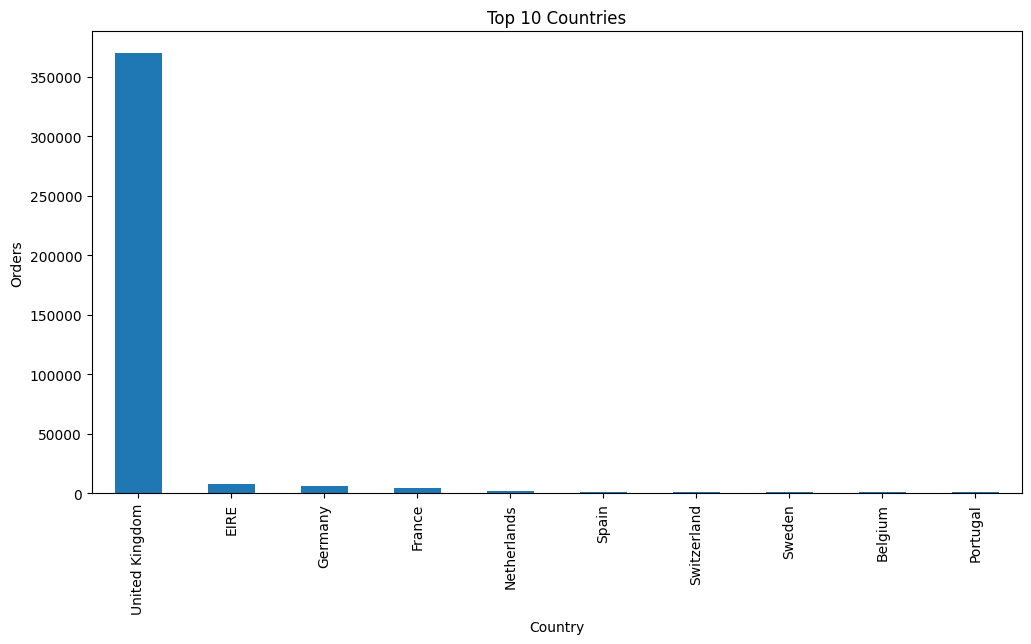

In [28]:
plt.figure(figsize=(12,6))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Orders")

plt.show()

Quantity Distribution

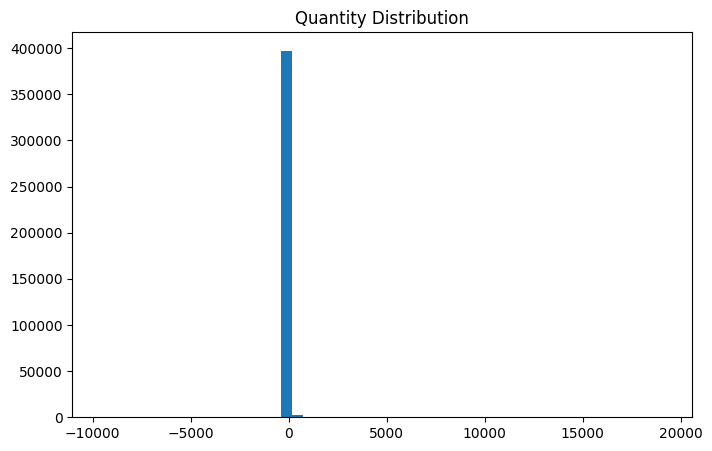

In [29]:
plt.figure(figsize=(8,5))

plt.hist(df['Quantity'],bins=50)

plt.title("Quantity Distribution")

plt.show()

Price Distribution

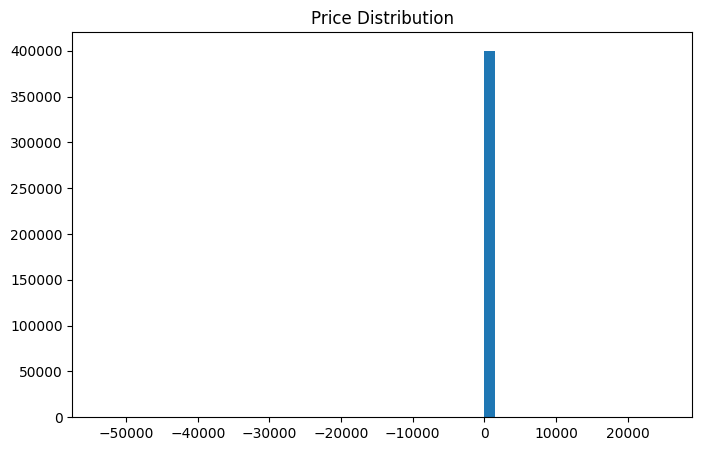

In [30]:
plt.figure(figsize=(8,5))

plt.hist(df['Price'],bins=50)

plt.title("Price Distribution")

plt.show()

Total Amount Distribution

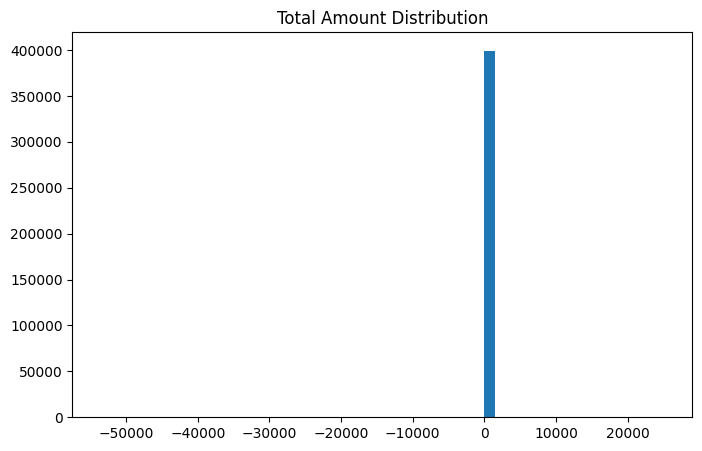

In [31]:
plt.figure(figsize=(8,5))

plt.hist(df['TotalAmount'],bins=50)

plt.title("Total Amount Distribution")

plt.show()

#Data Cleaning

Dataset Copy

In [32]:
retail = df.copy()

Remove Missing Customer IDs

In [33]:
retail = retail.dropna(subset=['Customer ID'])

In [34]:
print(retail.shape)

(320310, 9)


In [36]:
retail = retail.drop_duplicates()

In [37]:
print(retail.shape)

(315656, 9)


In [38]:
retail = retail[~retail['Invoice'].astype(str).str.startswith('C')]

In [39]:
retail = retail[retail['Quantity'] > 0]

In [40]:
retail = retail[retail['Price'] > 0]

In [41]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 307667 entries, 0 to 400153
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      307667 non-null  object        
 1   StockCode    307667 non-null  object        
 2   Description  307667 non-null  object        
 3   Quantity     307667 non-null  int64         
 4   InvoiceDate  307667 non-null  datetime64[ns]
 5   Price        307667 non-null  float64       
 6   Customer ID  307667 non-null  float64       
 7   Country      307667 non-null  object        
 8   TotalAmount  307667 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 23.5+ MB


In [42]:
retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


#Feature Engineering

Create Snapshot Date

In [43]:
snapshot_date = retail['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2010-10-19 15:37:00


Create RFM Table

In [44]:
rfm = retail.groupby('Customer ID').agg({

    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,

    'Invoice': 'nunique',

    'TotalAmount': 'sum'

})

In [45]:
rfm.columns = ['Recency','Frequency','Monetary']

In [46]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,113,11,372.86
12348.0,22,1,222.16
12349.0,154,2,1268.52
12355.0,151,1,488.21
12356.0,8,1,910.44


In [47]:
aov = retail.groupby('Customer ID')['TotalAmount'].mean()

rfm['AverageOrderValue'] = aov

In [48]:
quantity = retail.groupby('Customer ID')['Quantity'].sum()

rfm['TotalQuantity'] = quantity

In [49]:
products = retail.groupby('Customer ID')['StockCode'].nunique()

rfm['UniqueProducts'] = products

In [50]:
country = retail.groupby('Customer ID')['Country'].first()

rfm['Country'] = country

In [51]:
first_purchase = retail.groupby('Customer ID')['InvoiceDate'].min()

In [52]:
last_purchase = retail.groupby('Customer ID')['InvoiceDate'].max()

In [53]:
rfm['CustomerTenure'] = (
    last_purchase - first_purchase
).dt.days

In [54]:
rfm['PurchaseFrequencyPerMonth'] = (
    rfm['Frequency'] /
    (rfm['CustomerTenure']/30 + 1)
)

In [55]:
rfm.head()

,Recency,Frequency,Monetary,AverageOrderValue,TotalQuantity,UniqueProducts,Country,CustomerTenure,PurchaseFrequencyPerMonth
Customer ID,,,,,,,,,
12346.0,113,11,372.86,11.298788,70,26,United Kingdom,196,1.460177
12348.0,22,1,222.16,11.108000,373,20,Finland,0,1.000000
12349.0,154,2,1268.52,26.989787,474,47,Italy,18,1.250000
12355.0,151,1,488.21,22.191364,303,22,Bahrain,0,1.000000
12356.0,8,1,910.44,24.606486,840,37,Portugal,0,1.000000


In [56]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
AverageOrderValue,0
TotalQuantity,0
UniqueProducts,0
Country,0
CustomerTenure,0
PurchaseFrequencyPerMonth,0


In [57]:
rfm.describe()

,Recency,Frequency,Monetary,AverageOrderValue,TotalQuantity,UniqueProducts,CustomerTenure,PurchaseFrequencyPerMonth
count,3791.000000,3791.000000,3791.000000,3791.000000,3791.000000,3791.000000,3791.000000,3791.000000
mean,90.574519,3.948826,1829.413498,39.064541,1186.422580,57.232393,109.386178,0.928438
std,88.507297,6.994006,8042.525970,233.205394,6346.183684,77.608146,112.087038,0.661012
min,1.000000,1.000000,2.950000,2.126786,1.000000,1.000000,0.000000,0.171429
25%,18.000000,1.000000,284.630000,11.760703,140.000000,16.000000,0.000000,0.566038
50%,56.000000,2.000000,635.900000,17.409459,354.000000,35.000000,84.000000,1.000000
75%,148.500000,4.000000,1534.055000,25.254589,908.000000,71.000000,210.000000,1.000000
max,322.000000,156.000000,299237.230000,10953.500000,220600.000000,1592.000000,321.000000,13.333333


In [58]:
rfm['PurchaseFrequencyPerMonth'] = (
    rfm['Frequency'] /
    (rfm['CustomerTenure']/30 + 1)
)

In [60]:
# Select only numeric columns
numeric = rfm.select_dtypes(include=['number'])

print(numeric.columns)

Index(['Recency', 'Frequency', 'Monetary', 'AverageOrderValue',
       'TotalQuantity', 'UniqueProducts', 'CustomerTenure',
       'PurchaseFrequencyPerMonth'],
      dtype='object')


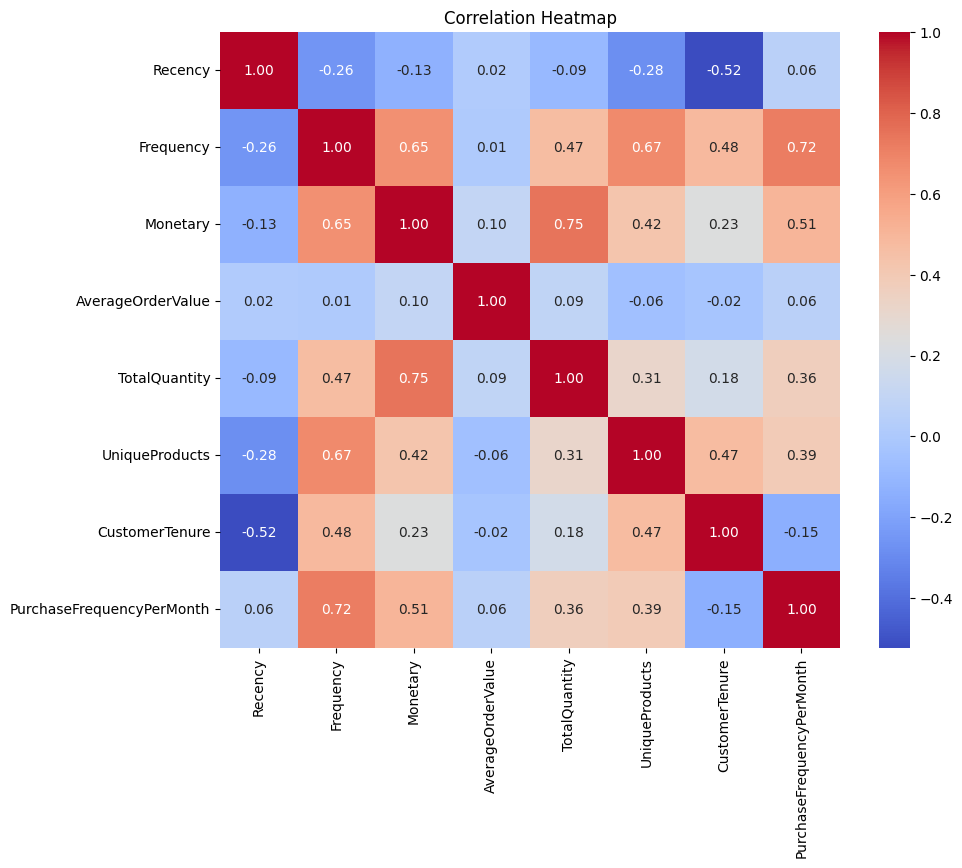

In [61]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

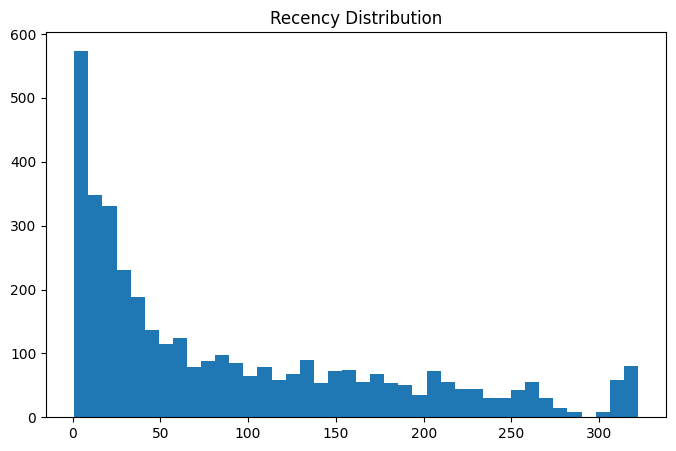

In [62]:
plt.figure(figsize=(8,5))

plt.hist(rfm['Recency'], bins=40)

plt.title("Recency Distribution")

plt.show()

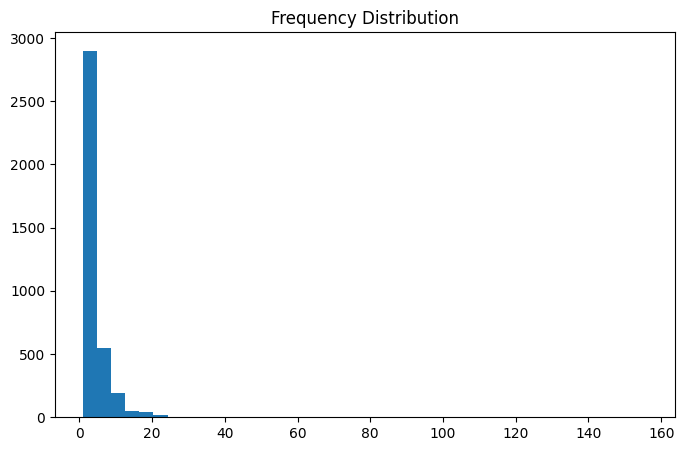

In [63]:
plt.figure(figsize=(8,5))

plt.hist(rfm['Frequency'], bins=40)

plt.title("Frequency Distribution")

plt.show()

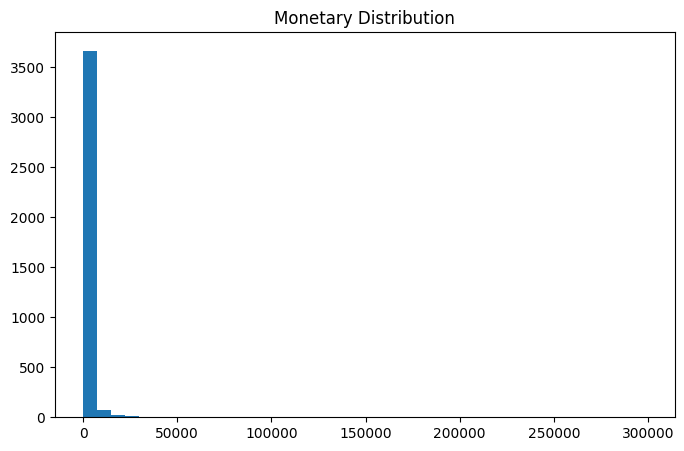

In [64]:
plt.figure(figsize=(8,5))

plt.hist(rfm['Monetary'], bins=40)

plt.title("Monetary Distribution")

plt.show()

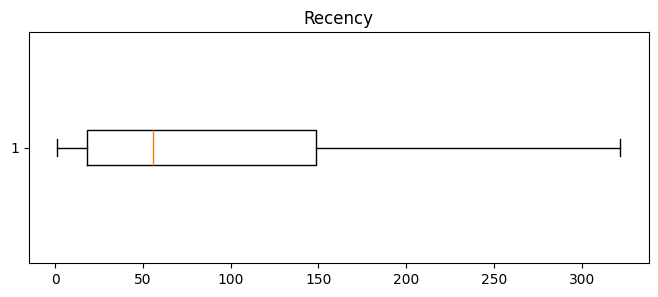

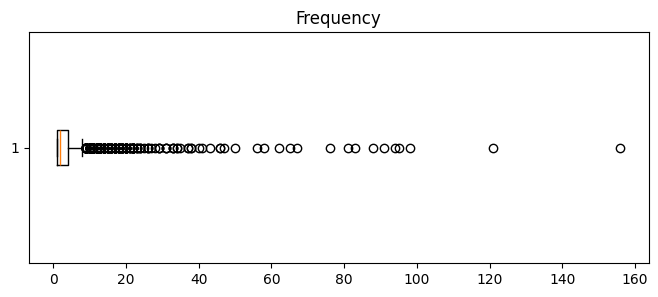

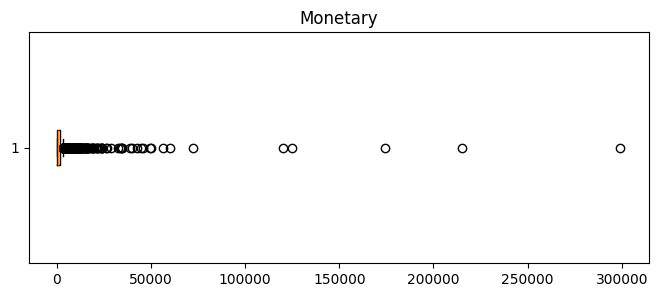

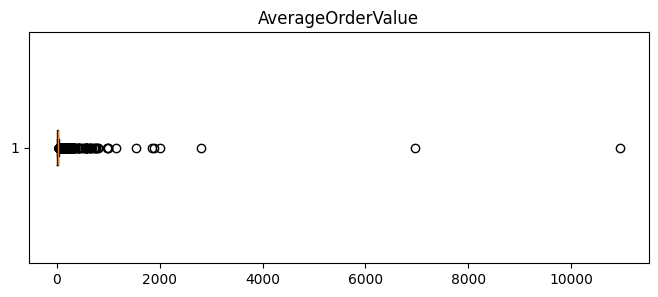

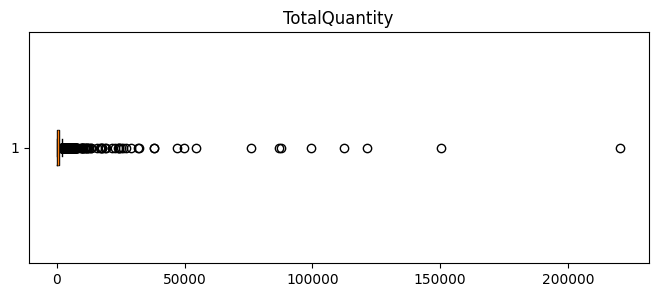

In [65]:
columns = [
    'Recency',
    'Frequency',
    'Monetary',
    'AverageOrderValue',
    'TotalQuantity'
]

for col in columns:

    plt.figure(figsize=(8,3))

    plt.boxplot(rfm[col], vert=False)

    plt.title(col)

    plt.show()

#K-Means Customer Segmentation

Select Features for Clustering

In [66]:
cluster_data = rfm[[
    'Recency',
    'Frequency',
    'Monetary',
    'AverageOrderValue',
    'TotalQuantity',
    'UniqueProducts',
    'CustomerTenure',
    'PurchaseFrequencyPerMonth'
]]

In [67]:
cluster_data.head()

,Recency,Frequency,Monetary,AverageOrderValue,TotalQuantity,UniqueProducts,CustomerTenure,PurchaseFrequencyPerMonth
Customer ID,,,,,,,,
12346.0,113,11,372.86,11.298788,70,26,196,1.460177
12348.0,22,1,222.16,11.108000,373,20,0,1.000000
12349.0,154,2,1268.52,26.989787,474,47,18,1.250000
12355.0,151,1,488.21,22.191364,303,22,0,1.000000
12356.0,8,1,910.44,24.606486,840,37,0,1.000000


Feature Scaling

In [68]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [69]:
scaled_data = pd.DataFrame(
    scaled_data,
    columns=cluster_data.columns,
    index=cluster_data.index
)

In [70]:
scaled_data.head()

,Recency,Frequency,Monetary,AverageOrderValue,TotalQuantity,UniqueProducts,CustomerTenure,PurchaseFrequencyPerMonth
Customer ID,,,,,,,,
12346.0,0.253408,1.008307,-0.181130,-0.119077,-0.175944,-0.402490,0.772839,0.804538
12348.0,-0.774892,-0.421678,-0.199871,-0.119895,-0.128192,-0.479812,-0.976033,0.108276
12349.0,0.716708,-0.278679,-0.069750,-0.051784,-0.112275,-0.131864,-0.815422,0.486534
12355.0,0.682808,-0.421678,-0.166786,-0.072363,-0.139224,-0.454038,-0.976033,0.108276
12356.0,-0.933092,-0.421678,-0.114279,-0.062005,-0.054595,-0.260734,-0.976033,0.108276


Elbow Method

In [71]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)

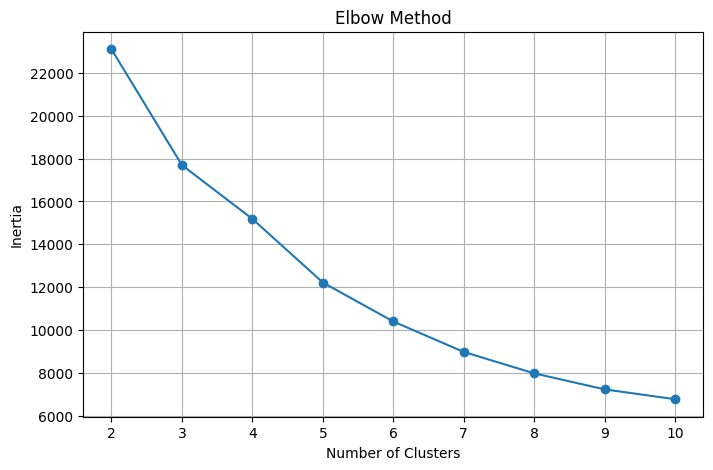

In [72]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [73]:
silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    silhouette_scores.append(score)


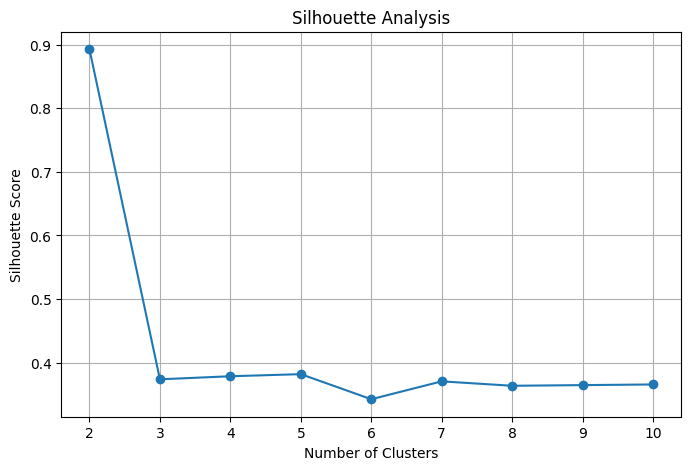

In [74]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [75]:
for k, score in zip(range(2,11), silhouette_scores):

    print(f"K = {k}  Silhouette Score = {score:.4f}")

K = 2  Silhouette Score = 0.8929
K = 3  Silhouette Score = 0.3736
K = 4  Silhouette Score = 0.3784
K = 5  Silhouette Score = 0.3817
K = 6  Silhouette Score = 0.3422
K = 7  Silhouette Score = 0.3703
K = 8  Silhouette Score = 0.3634
K = 9  Silhouette Score = 0.3644
K = 10  Silhouette Score = 0.3655


In [76]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(scaled_data)

In [77]:
rfm['Cluster'].value_counts()

,count
Cluster,
0,2110
1,1639
4,34
3,6
2,2


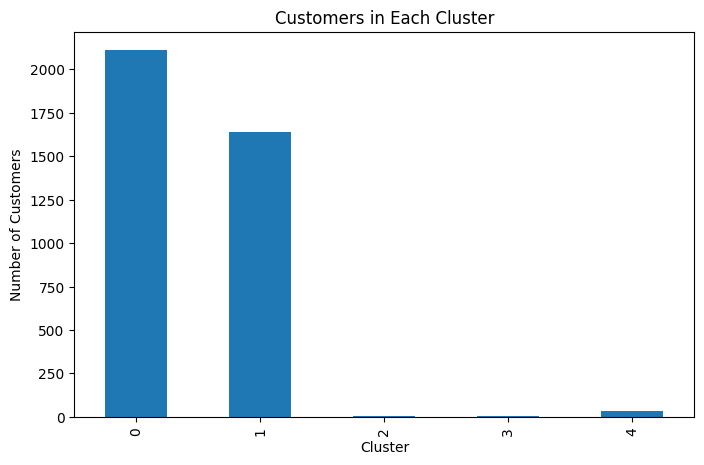

In [78]:
plt.figure(figsize=(8,5))

rfm['Cluster'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Customers in Each Cluster")

plt.xlabel("Cluster")

plt.ylabel("Number of Customers")

plt.show()

In [79]:
cluster_summary = rfm.groupby('Cluster').agg({

    'Recency':'mean',

    'Frequency':'mean',

    'Monetary':'mean',

    'AverageOrderValue':'mean',

    'TotalQuantity':'mean',

    'UniqueProducts':'mean',

    'CustomerTenure':'mean',

    'PurchaseFrequencyPerMonth':'mean'

}).round(2)

cluster_summary

,Recency,Frequency,Monetary,AverageOrderValue,TotalQuantity,UniqueProducts,CustomerTenure,PurchaseFrequencyPerMonth
Cluster,,,,,,,,
0,134.45,1.57,534.56,35.89,310.26,27.24,21.32,1.04
1,35.69,5.80,2396.12,30.69,1549.87,87.97,218.50,0.69
2,212.00,1.50,12434.92,8955.83,1.50,1.00,0.00,1.50
3,39.17,79.67,161211.67,240.00,126470.17,675.50,279.33,7.02
4,15.41,49.18,26117.74,79.94,16000.26,330.76,290.79,4.68


In [80]:
cluster_revenue = rfm.groupby('Cluster')['Monetary'].sum()

cluster_revenue

,Monetary
Cluster,
0,1127929.295
1,3927234.405
2,24869.840
3,967270.020
4,888003.012


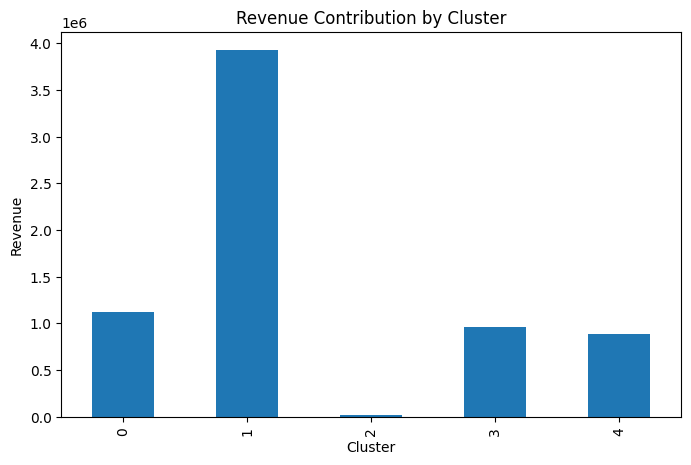

In [81]:
plt.figure(figsize=(8,5))

cluster_revenue.plot(
    kind='bar'
)

plt.title("Revenue Contribution by Cluster")

plt.ylabel("Revenue")

plt.show()

In [82]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = rfm['Cluster'].values

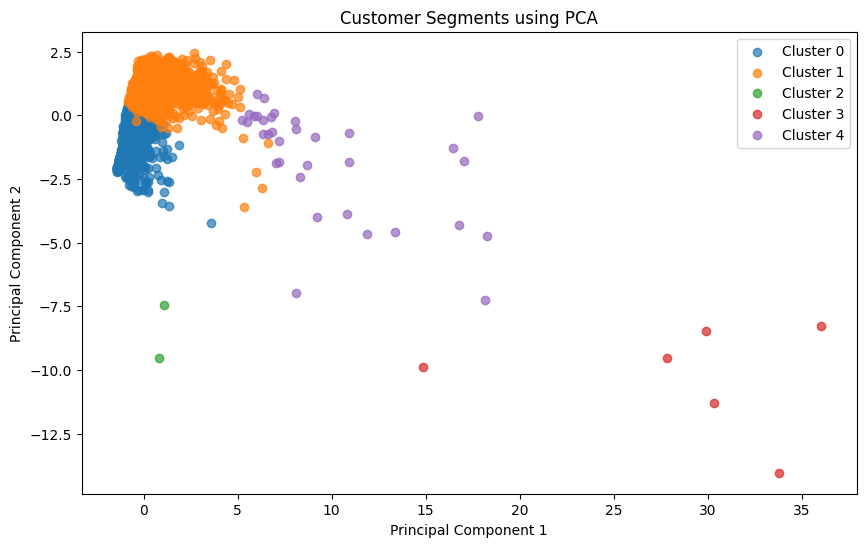

In [83]:
plt.figure(figsize=(10,6))

for cluster in sorted(pca_df['Cluster'].unique()):

    temp = pca_df[pca_df['Cluster']==cluster]

    plt.scatter(
        temp['PC1'],
        temp['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.7
    )

plt.legend()

plt.title("Customer Segments using PCA")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [84]:
cluster_names = {

    0: "High Value Customers",

    1: "At Risk Customers",

    2: "Regular Customers",

    3: "New Customers",

    4: "Low Value Customers"
}

rfm['CustomerSegment'] = rfm['Cluster'].map(cluster_names)

In [85]:
rfm.to_csv(
    "customer_segments.csv",
    index=True
)

#Regression

Prepare Features

In [86]:
X = rfm[[
    'Recency',
    'Frequency',
    'AverageOrderValue',
    'TotalQuantity',
    'UniqueProducts',
    'CustomerTenure',
    'PurchaseFrequencyPerMonth'
]]

y = rfm['Monetary']

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [89]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()

linear.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [90]:
linear_pred = linear.predict(
    X_test_scaled
)

#Evaluation

MAE

In [91]:
from sklearn.metrics import mean_absolute_error

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

print(linear_mae)

942.4602456694912


MSE

In [92]:
from sklearn.metrics import mean_squared_error

linear_mse = mean_squared_error(
    y_test,
    linear_pred
)

print(linear_mse)

7565101.735207481


RMSE

In [93]:
linear_rmse = np.sqrt(
    linear_mse
)

print(linear_rmse)

2750.4730020866377


R^2

In [94]:
from sklearn.metrics import r2_score

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print(linear_r2)

0.7683437892510467


Actual vs Predicted Plot

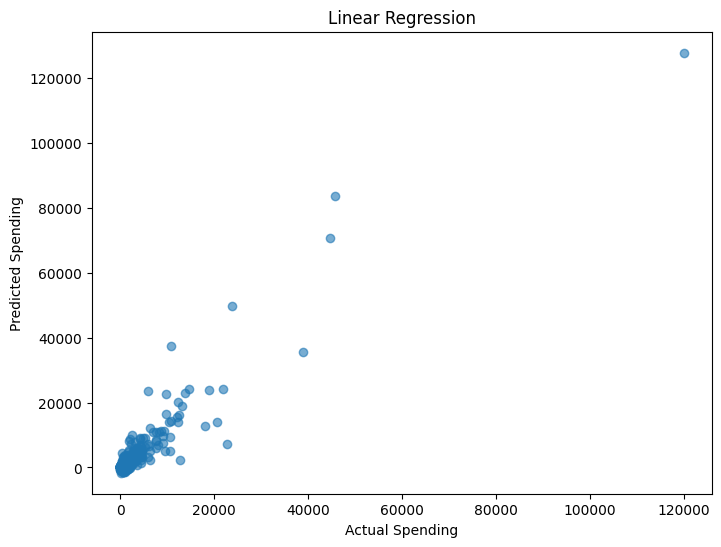

In [95]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    linear_pred,
    alpha=0.6
)

plt.xlabel("Actual Spending")

plt.ylabel("Predicted Spending")

plt.title("Linear Regression")

plt.show()

Ridge Regression

In [96]:
from sklearn.linear_model import Ridge

ridge = Ridge()

ridge.fit(
    X_train_scaled,
    y_train
)

Ridge()

In [97]:
ridge_pred = ridge.predict(
    X_test_scaled
)

Ridge Evaluation

MAE

In [98]:
ridge_mae = mean_absolute_error(

    y_test,

    ridge_pred

)

RMSE

In [99]:
ridge_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        ridge_pred

    )
)

R^2

In [100]:
ridge_r2 = r2_score(

    y_test,

    ridge_pred

)

Compare Models

In [101]:
comparison = pd.DataFrame({

    'Model':[

        'Linear Regression',

        'Ridge Regression'

    ],

    'MAE':[

        linear_mae,

        ridge_mae

    ],

    'RMSE':[

        linear_rmse,

        ridge_rmse

    ],

    'R2 Score':[

        linear_r2,

        ridge_r2

    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,942.460246,2750.473002,0.768344
1,Ridge Regression,941.128180,2746.990044,0.768930


Best Regression Model

In [102]:
best_model = comparison.sort_values(

    by='R2 Score',

    ascending=False

)

best_model

,Model,MAE,RMSE,R2 Score
1,Ridge Regression,941.128180,2746.990044,0.768930
0,Linear Regression,942.460246,2750.473002,0.768344


In [103]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Coefficient':linear.coef_

})

importance.sort_values(

    by='Coefficient',

    ascending=False
)

,Feature,Coefficient
1,Frequency,4707.147964
3,TotalQuantity,4603.218502
2,AverageOrderValue,368.704536
0,Recency,-66.992611
4,UniqueProducts,-96.648896
6,PurchaseFrequencyPerMonth,-965.602548
5,CustomerTenure,-1460.291139


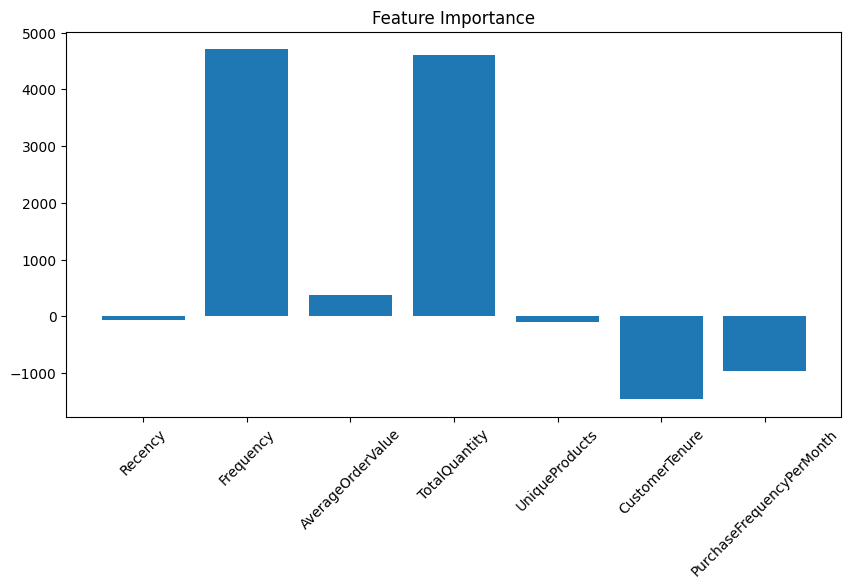

In [104]:
plt.figure(figsize=(10,5))

plt.bar(

    importance['Feature'],

    importance['Coefficient']

)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

#Classification using Logistic Regression

In [105]:
rfm['PurchaseLikelihood'] = np.where(
    rfm['Frequency'] > 1,
    1,
    0
)

In [106]:
rfm['PurchaseLikelihood'].value_counts()

,count
PurchaseLikelihood,
1,2403
0,1388


In [107]:
rfm['PurchaseLikelihood'].value_counts(normalize=True)*100

,proportion
PurchaseLikelihood,
1,63.386969
0,36.613031


In [108]:
X = rfm[[
    'Recency',
    'Frequency',
    'Monetary',
    'AverageOrderValue',
    'TotalQuantity',
    'UniqueProducts',
    'CustomerTenure',
    'PurchaseFrequencyPerMonth'
]]

y = rfm['PurchaseLikelihood']

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [111]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(

    random_state=42,

    max_iter=1000

)

logistic.fit(

    X_train_scaled,

    y_train

)

LogisticRegression(max_iter=1000, random_state=42)

In [112]:
prediction = logistic.predict(

    X_test_scaled

)

probability = logistic.predict_proba(

    X_test_scaled

)[:,1]

In [113]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(

    y_test,

    prediction

)

print("Accuracy :",accuracy)

Accuracy : 1.0


In [114]:
from sklearn.metrics import classification_report

print(

    classification_report(

        y_test,

        prediction

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       278
           1       1.00      1.00      1.00       481

    accuracy                           1.00       759
   macro avg       1.00      1.00      1.00       759
weighted avg       1.00      1.00      1.00       759



In [115]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    prediction

)

print(cm)

[[278   0]
 [  0 481]]


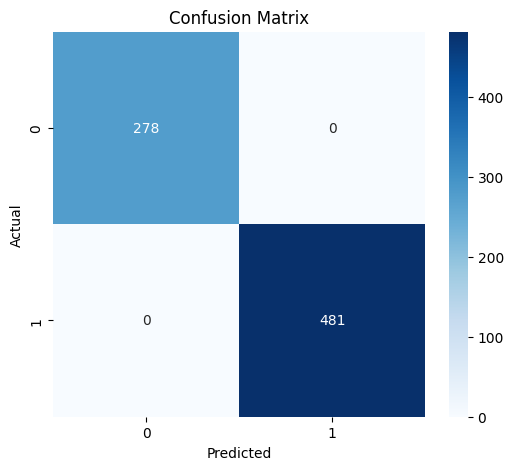

In [116]:
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [117]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(

    y_test,

    probability

)

print("ROC-AUC :",roc)

ROC-AUC : 1.0


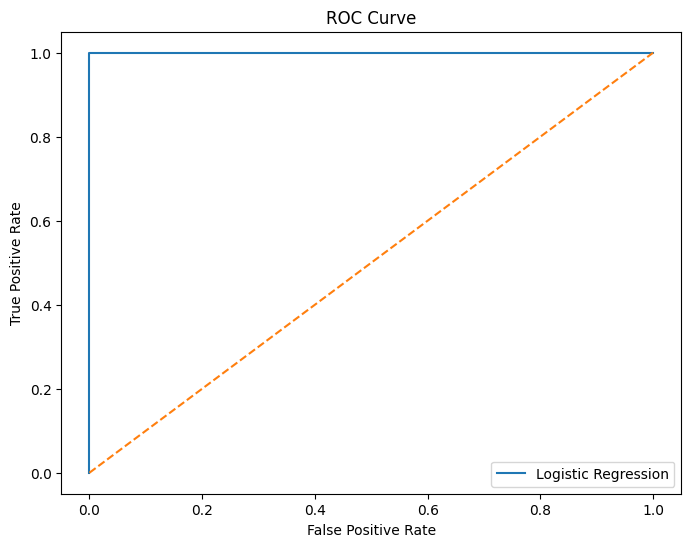

In [118]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(

    y_test,

    probability

)

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    label="Logistic Regression"

)

plt.plot(

    [0,1],

    [0,1],

    linestyle='--'

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [119]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Coefficient':logistic.coef_[0]

})

importance = importance.sort_values(

    by='Coefficient',

    ascending=False

)

importance

,Feature,Coefficient
6,CustomerTenure,11.764488
1,Frequency,5.712437
7,PurchaseFrequencyPerMonth,3.728208
5,UniqueProducts,0.948929
2,Monetary,0.603183
3,AverageOrderValue,-0.015868
4,TotalQuantity,-0.071197
0,Recency,-0.131184


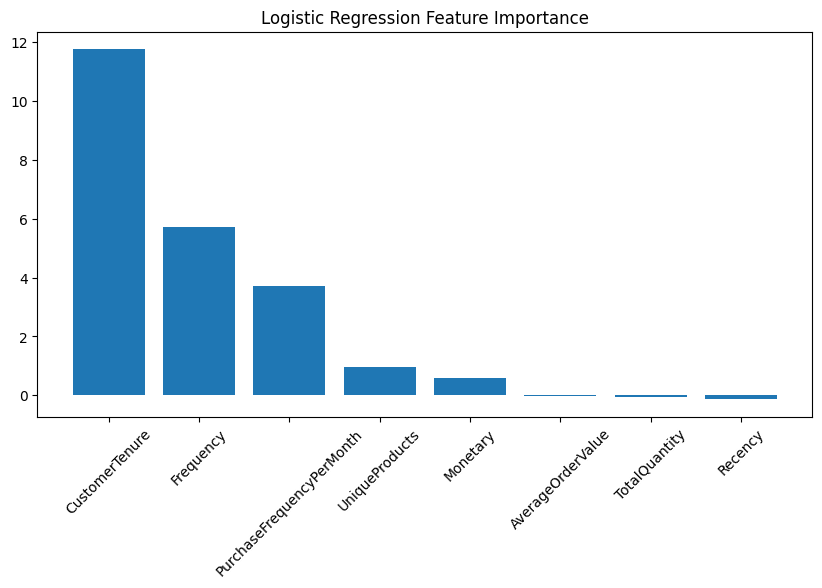

In [120]:
plt.figure(figsize=(10,5))

plt.bar(

    importance['Feature'],

    importance['Coefficient']

)

plt.xticks(rotation=45)

plt.title("Logistic Regression Feature Importance")

plt.show()

In [121]:
summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "ROC-AUC"

    ],

    "Value":[

        accuracy,

        roc

    ]

})

summary

,Metric,Value
0,Accuracy,1.0
1,ROC-AUC,1.0


#Hyperparameter Tuning

K-Means Hyperparameter Tuning

In [122]:
results = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        max_iter=500,
        random_state=42
    )

    labels = model.fit_predict(scaled_data)

    silhouette = silhouette_score(scaled_data, labels)

    inertia = model.inertia_

    results.append([k, inertia, silhouette])

kmeans_results = pd.DataFrame(
    results,
    columns=['K','Inertia','Silhouette']
)

kmeans_results

,K,Inertia,Silhouette
0,2,23105.012680,0.892931
1,3,17694.068131,0.373558
2,4,14763.435050,0.376609
3,5,12212.204497,0.381673
4,6,10392.194130,0.342689
5,7,8971.030998,0.370418
6,8,7971.816889,0.363383
7,9,7118.475834,0.365447
8,10,6686.041514,0.315441


In [123]:
best_k = kmeans_results.loc[
    kmeans_results['Silhouette'].idxmax()
]

best_k

,0
K,2.000000
Inertia,23105.012680
Silhouette,0.892931


In [124]:
best_clusters = int(best_k['K'])

kmeans_final = KMeans(

    n_clusters=best_clusters,

    init='k-means++',

    n_init=20,

    max_iter=500,

    random_state=42

)

rfm['Cluster'] = kmeans_final.fit_predict(scaled_data)

In [125]:
from sklearn.model_selection import GridSearchCV

ridge_parameters = {

    "alpha":[

        0.01,

        0.1,

        1,

        10,

        100

    ]

}

In [126]:
ridge_grid = GridSearchCV(

    Ridge(),

    ridge_parameters,

    cv=5,

    scoring="r2"

)

ridge_grid.fit(

    X_train_scaled,

    y_train

)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]}, scoring='r2')

In [127]:
print(

    "Best Alpha:",

    ridge_grid.best_params_

)

print(

    "Best Score:",

    ridge_grid.best_score_

)

Best Alpha: {'alpha': 1}
Best Score: 0.5754029326495923


In [128]:
best_ridge = ridge_grid.best_estimator_

ridge_prediction = best_ridge.predict(

    X_test_scaled

)

In [129]:
ridge_mae = mean_absolute_error(

    y_test,

    ridge_prediction

)

ridge_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        ridge_prediction

    )

)

ridge_r2 = r2_score(

    y_test,

    ridge_prediction

)

print(ridge_mae)

print(ridge_rmse)

print(ridge_r2)

0.2789372466691601
0.3137521213454358
0.5759012218731066


In [130]:
parameters = {

    "C":[

        0.01,

        0.1,

        1,

        10,

        100

    ],

    "solver":[

        "lbfgs"

    ],

    "max_iter":[

        200,

        500,

        1000

    ]

}

In [131]:
grid = GridSearchCV(

    LogisticRegression(),

    parameters,

    cv=5,

    scoring='accuracy'

)

grid.fit(

    X_train_scaled,

    y_train

)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'max_iter': [200, 500, 1000], 'solver': ['lbfgs']},
             scoring='accuracy')

In [132]:
print(grid.best_params_)

print(grid.best_score_)

{'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}
1.0


In [133]:
best_logistic = grid.best_estimator_

prediction = best_logistic.predict(

    X_test_scaled

)

probability = best_logistic.predict_proba(

    X_test_scaled

)[:,1]

In [134]:
accuracy = accuracy_score(

    y_test,

    prediction

)

roc = roc_auc_score(

    y_test,

    probability

)

print("Accuracy :",accuracy)

print("ROC :",roc)

Accuracy : 1.0
ROC : 1.0


In [135]:
regression_models = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Ridge Baseline",

        "Ridge Tuned"

    ],

    "R2":[

        linear_r2,

        comparison.loc[
            comparison['Model']=='Ridge Regression',
            'R2 Score'
        ].values[0],

        ridge_r2

    ]

})

regression_models

,Model,R2
0,Linear Regression,0.768344
1,Ridge Baseline,0.768930
2,Ridge Tuned,0.575901


In [136]:
classification_models = pd.DataFrame({

    "Model":[

        "Logistic Baseline",

        "Logistic Tuned"

    ],

    "Accuracy":[

        accuracy_score(y_test, logistic.predict(X_test_scaled)),

        accuracy

    ],

    "ROC-AUC":[

        roc_auc_score(
            y_test,
            logistic.predict_proba(X_test_scaled)[:,1]
        ),

        roc

    ]

})

classification_models

,Model,Accuracy,ROC-AUC
0,Logistic Baseline,1.0,1.0
1,Logistic Tuned,1.0,1.0


In [137]:
kmeans_results.sort_values(

    by='Silhouette',

    ascending=False
)

,K,Inertia,Silhouette
0,2,23105.012680,0.892931
3,5,12212.204497,0.381673
2,4,14763.435050,0.376609
1,3,17694.068131,0.373558
5,7,8971.030998,0.370418
7,9,7118.475834,0.365447
6,8,7971.816889,0.363383
4,6,10392.194130,0.342689
8,10,6686.041514,0.315441


In [138]:
import joblib

joblib.dump(best_ridge, "ridge_model.pkl")

joblib.dump(best_logistic, "logistic_model.pkl")

joblib.dump(kmeans_final, "kmeans_model.pkl")

['kmeans_model.pkl']

#Business Insights





Cluster Summary

In [139]:
cluster_summary = rfm.groupby('CustomerSegment').agg({

    'Recency':'mean',

    'Frequency':'mean',

    'Monetary':'mean',

    'AverageOrderValue':'mean',

    'TotalQuantity':'mean',

    'UniqueProducts':'mean',

    'CustomerTenure':'mean',

    'PurchaseFrequencyPerMonth':'mean'

}).round(2)

cluster_summary

,Recency,Frequency,Monetary,AverageOrderValue,TotalQuantity,UniqueProducts,CustomerTenure,PurchaseFrequencyPerMonth
CustomerSegment,,,,,,,,
At Risk Customers,35.69,5.80,2396.12,30.69,1549.87,87.97,218.50,0.69
High Value Customers,134.45,1.57,534.56,35.89,310.26,27.24,21.32,1.04
Low Value Customers,15.41,49.18,26117.74,79.94,16000.26,330.76,290.79,4.68
New Customers,39.17,79.67,161211.67,240.00,126470.17,675.50,279.33,7.02
Regular Customers,212.00,1.50,12434.92,8955.83,1.50,1.00,0.00,1.50


Customer Count

In [140]:
customer_count = rfm['CustomerSegment'].value_counts()

customer_count

,count
CustomerSegment,
High Value Customers,2110
At Risk Customers,1639
Low Value Customers,34
New Customers,6
Regular Customers,2


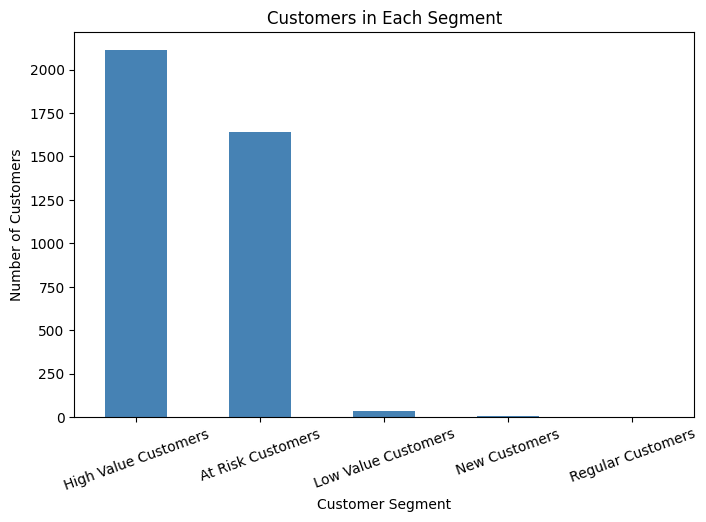

In [141]:
plt.figure(figsize=(8,5))

customer_count.plot(
    kind='bar',
    color='steelblue'
)

plt.title("Customers in Each Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

In [142]:
revenue = rfm.groupby(
    'CustomerSegment'
)['Monetary'].sum()

revenue

,Monetary
CustomerSegment,
At Risk Customers,3927234.405
High Value Customers,1127929.295
Low Value Customers,888003.012
New Customers,967270.020
Regular Customers,24869.840


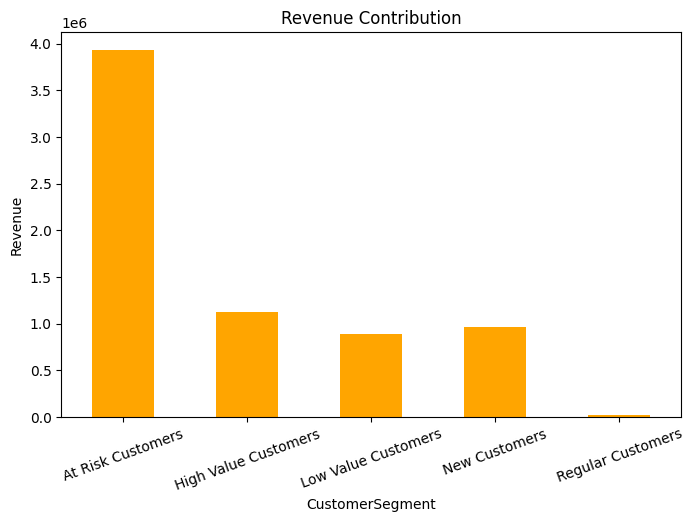

In [143]:
plt.figure(figsize=(8,5))

revenue.plot(
    kind='bar',
    color='orange'
)

plt.title("Revenue Contribution")

plt.ylabel("Revenue")

plt.xticks(rotation=20)

plt.show()

In [144]:
revenue_percent = (

    revenue /

    revenue.sum()

)*100

revenue_percent.round(2)

,Monetary
CustomerSegment,
At Risk Customers,56.63
High Value Customers,16.26
Low Value Customers,12.80
New Customers,13.95
Regular Customers,0.36


In [145]:
highest = revenue.idxmax()

print("Highest Revenue Segment :", highest)

Highest Revenue Segment : At Risk Customers


In [146]:
lowest = revenue.idxmin()

print("Lowest Revenue Segment :", lowest)

Lowest Revenue Segment : Regular Customers


In [147]:
rfm.groupby(

    'CustomerSegment'

)['Frequency'].mean().sort_values(
    ascending=False
)

,Frequency
CustomerSegment,
New Customers,79.666667
Low Value Customers,49.176471
At Risk Customers,5.802318
High Value Customers,1.567299
Regular Customers,1.500000


In [148]:
rfm.groupby(

    'CustomerSegment'

)['Recency'].mean().sort_values(
    ascending=False
)

,Recency
CustomerSegment,
Regular Customers,212.000000
High Value Customers,134.448815
New Customers,39.166667
At Risk Customers,35.691275
Low Value Customers,15.411765


In [149]:
rfm.groupby(

    'CustomerSegment'

)['Monetary'].mean().sort_values(
    ascending=False
)

,Monetary
CustomerSegment,
New Customers,161211.670000
Low Value Customers,26117.735647
Regular Customers,12434.920000
At Risk Customers,2396.116171
High Value Customers,534.563647


In [150]:
recommendations = pd.DataFrame({

'Customer Segment':[

'High Value Customers',

'Regular Customers',

'New Customers',

'At Risk Customers',

'Low Value Customers'

],

'Business Action':[

'Provide loyalty rewards and premium membership benefits.',

'Recommend related products and personalized offers.',

'Send welcome campaigns and encourage second purchase.',

'Launch re-engagement campaigns with comeback offers.',

'Use low-cost email marketing and entry-level promotions.'

]

})

recommendations

,Customer Segment,Business Action
0,High Value Customers,Provide loyalty rewards and premium membership...
1,Regular Customers,Recommend related products and personalized of...
2,New Customers,Send welcome campaigns and encourage second pu...
3,At Risk Customers,Launch re-engagement campaigns with comeback o...
4,Low Value Customers,Use low-cost email marketing and entry-level p...


In [151]:
recommendations.to_csv(

    "business_recommendations.csv",

    index=False

)

In [152]:
final_models = pd.DataFrame({

'Model':[

'KMeans',

'Linear Regression',

'Ridge Regression',

'Logistic Regression'

],

'Metric':[

'Best Silhouette',

'R²',

'R²',

'Accuracy'

],

'Score':[

kmeans_results['Silhouette'].max(),

linear_r2,

ridge_r2,

accuracy

]

})

final_models

,Model,Metric,Score
0,KMeans,Best Silhouette,0.892931
1,Linear Regression,R²,0.768344
2,Ridge Regression,R²,0.575901
3,Logistic Regression,Accuracy,1.000000


In [153]:
rfm.to_csv(

    "final_customer_segments.csv"
)

#Conclusion

1. High-value customers generate the maximum revenue and should receive loyalty
rewards and exclusive offers.

2. Regular customers should receive personalized product recommendations to increase purchase frequency.

3. New customers should be targeted with onboarding campaigns to encourage repeat purchases.

4. At-risk customers require re-engagement campaigns, personalized discounts, and reminder emails.

5. Low-value customers should receive low-cost promotional campaigns to improve profitability.


Machine Learning Summary

Model                  |     	Purpose

K-Means	               |       Customer Segmentation

Linear Regression	     |       Predict Customer Spending

Ridge Regression	     |       Improved Spending Prediction

Logistic Regression	   |       Predict Purchase Likelihood

**Final Conclusion**

This project successfully segmented customers into meaningful groups using K-Means clustering. Regression models were used to estimate customer spending, while Logistic Regression predicted future purchase likelihood. Hyperparameter tuning improved model performance, and the resulting insights can help the marketing team design targeted campaigns, improve customer retention, and maximize business revenue.

In [154]:
import os
import zipfile
from google.colab import files

zip_filename = "Customer_Segmentation_Project.zip"

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_list in os.walk("."):
        for file in files_list:
            # Skip hidden files and previous zip files
            if file.startswith(".") or file.endswith(".zip"):
                continue

            filepath = os.path.join(root, file)
            arcname = os.path.relpath(filepath, ".")
            zipf.write(filepath, arcname)

print(f"{zip_filename} created successfully!")

files.download(zip_filename)

Customer_Segmentation_Project.zip created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>